In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

master_df = pd.read_csv('../data/processed/master_weekly.csv', index_col=0, parse_dates=True)
print(master_df.shape)

(730, 19)


In [12]:
# Select the same features used in Random Forest, plus the target
features_list = ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath',
                  'cpi', 'unemployment', 'interest_rate', 'num_ili']
target = 'XLV_vol'

# Create lag features same as before
lstm_df = pd.DataFrame(index=master_df.index)
for col in features_list:
    for lag in range(1, 5):
        lstm_df[f'{col}_lag{lag}'] = master_df[col].shift(lag)

lstm_df[target] = master_df[target]
lstm_df = lstm_df.dropna()

print(lstm_df.shape)
print(lstm_df.head())

(726, 33)
            wili_lag1  wili_lag2  wili_lag3  wili_lag4  \
2010-02-07   1.969084   1.880723   1.867375   1.907118   
2010-02-14   2.113868   1.969084   1.880723   1.867375   
2010-02-21   2.096946   2.113868   1.969084   1.880723   
2010-02-28   1.902943   2.096946   2.113868   1.969084   
2010-03-07   1.969515   1.902943   2.096946   2.113868   

            trends_flu_symptoms_lag1  trends_flu_symptoms_lag2  \
2010-02-07                      10.0                      11.0   
2010-02-14                      10.0                      10.0   
2010-02-21                       9.0                      10.0   
2010-02-28                       8.0                       9.0   
2010-03-07                       8.0                       8.0   

            trends_flu_symptoms_lag3  trends_flu_symptoms_lag4  \
2010-02-07                      13.0                      14.0   
2010-02-14                      11.0                      13.0   
2010-02-21                      10.0          

In [13]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
X = lstm_df.drop(columns=[target]).values
y = lstm_df[target].values.reshape(-1, 1)

print(X.shape)
print(y.shape)

(726, 32)
(726, 1)


In [14]:
from sklearn.model_selection import train_test_split

split_idx = int(len(X) * 0.8)

X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
y_train_raw, y_test_raw = y[:split_idx], y[split_idx:]

train_dates = lstm_df.index[:split_idx]
test_dates = lstm_df.index[split_idx:]

# Fit scalers on train only — test set never influences the scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled = scaler_X.transform(X_test_raw)  # transform only, no fit
y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_test_scaled = scaler_y.transform(y_test_raw)  # transform only, no fit

# Reshape into LSTM 3D input after scaling
X_train = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))
y_train = y_train_scaled
y_test = y_test_scaled

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test dates: {test_dates.min()} to {test_dates.max()}")

Train: (580, 1, 32), Test: (146, 1, 32)
Train dates: 2010-02-07 00:00:00 to 2021-03-14 00:00:00
Test dates: 2021-03-21 00:00:00 to 2023-12-31 00:00:00


Architecture note: This model uses a timestep dimension of 1 — each sample is a single row containing pre-computed lag features (e.g. wili_lag1–lag4) rather than a true multi-step time sequence. Because of this, the LSTM layer is not using its core mechanism — recurrent memory carried across timesteps. It is functionally equivalent to a dense feedforward layer operating on the same flattened lag features, just with more parameters and compute overhead. The model is still a valid comparison point against ARIMA+RF in this report, but it should be read as "LSTM-shaped" rather than a true sequence model leveraging temporal memory. A future iteration could restructure inputs into genuine multi-step sequences (raw, unlagged features stacked across a rolling window) to make use of the LSTM's intended recurrent capability

In [15]:
import tensorflow as tf
tf.random.set_seed(42)

# Carve validation out of train only — never touch test here
val_split_idx = int(len(X_train) * 0.85)
X_train_fit, X_val = X_train[:val_split_idx], X_train[val_split_idx:]
y_train_fit, y_val = y_train[:val_split_idx], y_train[val_split_idx:]

model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(
    X_train_fit, y_train_fit,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50


C:\Users\khavk\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0118 - val_loss: 0.0329
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0068 - val_loss: 0.0360
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0067 - val_loss: 0.0360
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 - val_loss: 0.0361
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 - val_loss: 0.0361
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065 - val_loss: 0.0363
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065 - val_loss: 0.0367
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065 - val_loss: 0.0365
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064 - val_loss: 0.0365
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0063 - val_loss: 0.0359
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064 - val_loss: 0.0362
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0063 - val_loss: 0.0366

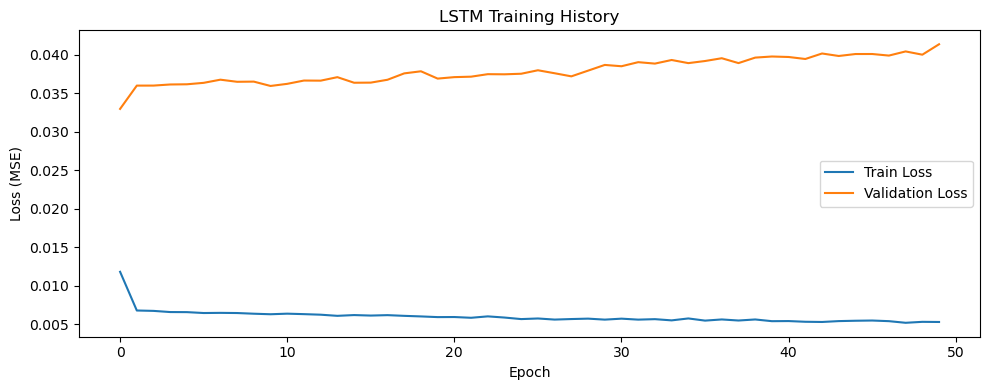

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot17_lstm_training.png', dpi=150)
plt.show()

Overfitting note: Training loss converges to ~0.005 while validation loss plateaus around 0.035–0.04 and never closes the gap — the model is fitting noise specific to the training window rather than learning a generalizable pattern. A simpler architecture (fewer LSTM units, higher dropout, early stopping) would likely narrow this gap, but given the consistent negative out-of-sample results across three other independent model families (spike classifier, ARIMA+RF, and this model's own COVID-period evaluation), reducing model complexity is not expected to produce a positive R² — the limiting factor appears to be the absence of predictive signal in pre-crisis data, not excess model capacity.

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_scaled = model.predict(X_test)

# Inverse transform back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"LSTM RMSE: {rmse:.6f}")
print(f"LSTM R²: {r2:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
LSTM RMSE: 0.004127
LSTM R²: -0.1401


In [18]:
# Build a separate pre-2020-only training set — COVID must be fully excluded from training
train_mask_pre2020 = lstm_df.index < '2020-01-01'
covid_mask = (lstm_df.index >= '2020-01-01') & (lstm_df.index <= '2021-01-01')

X_pre2020_raw = X[train_mask_pre2020]
y_pre2020_raw = y[train_mask_pre2020]
X_covid_raw = X[covid_mask]
y_covid_raw = y[covid_mask]

# Fresh scalers fit on pre-2020 data only — keeps this evaluation fully separate from the main split
scaler_X_covid = MinMaxScaler()
scaler_y_covid = MinMaxScaler()

X_pre2020_scaled = scaler_X_covid.fit_transform(X_pre2020_raw)
X_covid_scaled = scaler_X_covid.transform(X_covid_raw)
y_pre2020_scaled = scaler_y_covid.fit_transform(y_pre2020_raw)
y_covid_scaled = scaler_y_covid.transform(y_covid_raw)

X_pre2020_lstm = X_pre2020_scaled.reshape((X_pre2020_scaled.shape[0], 1, X_pre2020_scaled.shape[1]))
X_covid_lstm = X_covid_scaled.reshape((X_covid_scaled.shape[0], 1, X_covid_scaled.shape[1]))

# Fresh model — must not be the same model object trained on data through 2021
tf.random.set_seed(42)
model_covid = Sequential([
    LSTM(64, activation='relu', input_shape=(X_pre2020_lstm.shape[1], X_pre2020_lstm.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model_covid.compile(optimizer='adam', loss='mse')
model_covid.fit(X_pre2020_lstm, y_pre2020_scaled, epochs=50, batch_size=16, verbose=0)

y_covid_pred_scaled = model_covid.predict(X_covid_lstm)
y_covid_pred = scaler_y_covid.inverse_transform(y_covid_pred_scaled)
y_covid_actual = scaler_y_covid.inverse_transform(y_covid_scaled)

rmse_covid = np.sqrt(mean_squared_error(y_covid_actual, y_covid_pred))
r2_covid = r2_score(y_covid_actual, y_covid_pred)

print(f"LSTM COVID RMSE (pre-2020 train only): {rmse_covid:.6f}")
print(f"LSTM COVID R² (pre-2020 train only): {r2_covid:.4f}")

C:\Users\khavk\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
LSTM COVID RMSE (pre-2020 train only): 0.014786
LSTM COVID R² (pre-2020 train only): -0.2703
